<a href="https://colab.research.google.com/github/yassni-s/Diplomado-en-ingenieria-ciencia-de-datos/blob/main/Copia_de_Capitulo1_SaberPro_PySpark_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 CAPÍTULO 1. COMPRENSIÓN DEL CONTEXTO Y DE LOS DATOS SABER PRO
---
## Análisis Descriptivo de Brechas Socioeconómicas y Desempeño Académico
### Pruebas Saber Pro — Departamento del Cauca (2018–2022)

| Campo | Detalle |
|---|---|
| **Autoras** | Claudia Elizabeth Mejía Cuásquer · Yaseni Silva Bolaños |
| **Tutor** | Francisco Javier Ovando |
| **Institución** | Corporación Universitaria Comfacauca — Unicomfacauca |
| **Diplomado** | Ingeniería y Ciencia de Datos Aplicada (2026-1) |
| **Metodología** | CRISP-DM — Fase 1: Comprensión del Negocio + Fase 2: Comprensión de los Datos |
| **Motor** | Apache PySpark (1.217.482 registros) |

---
### 📋 Estructura del Capítulo

| Sección | Contenido |
|---|---|
| 1.1 | Identificación del problema de análisis |
| 1.2 | Delimitación del alcance del estudio |
| 1.3 | Contexto de las Pruebas Saber Pro |
| 1.4 | Instalación, librerías y SparkSession |
| 1.5 | Montar Google Drive y verificar el dataset |
| 1.6 | Cargar el dataset completo con PySpark |
| 1.7 | Estructura general del dataset |
| 1.8 | Selección de las 15 variables del proyecto |
| 1.9 | Revisión inicial de calidad de datos |
| 1.10 | Filtrar registros del Cauca 2018–2022 |
| 1.11 | Guardar dataset procesado en Google Drive |

---
> ⚠️ **REQUISITO PREVIO:** El archivo `Resultados__nicos_Saber_Pro.csv` debe estar  
> en Google Drive → Mi unidad → SaberPro (tamaño esperado: ~640 MB)

---
## 1.1 Identificación del problema de análisis

Las Instituciones de Educación Superior (IES) del departamento del Cauca carecen de un análisis sistemático y longitudinal del desempeño de sus estudiantes universitarios en las Pruebas Saber Pro durante el período 2018–2022. Esta situación impide identificar con precisión las brechas académicas asociadas a condiciones socioeconómicas, familiares, laborales e institucionales que limitan la competitividad educativa regional frente al promedio nacional.

**Pregunta central:**
> ¿Cuáles son los factores socioeconómicos, geográficos e institucionales asociados a las brechas de desempeño académico en las Pruebas Saber Pro (2018–2022) de los estudiantes universitarios del departamento del Cauca, y cómo estos limitan la competitividad educativa regional?

---
## 1.2 Delimitación del alcance del estudio

| Criterio | Detalle |
|---|---|
| **Población** | Estudiantes universitarios de pregrado de IES del Cauca |
| **Período** | 2018–2022 (10 semestres consecutivos) |
| **Fuente** | Dataset oficial ICFES — datos.gov.co |
| **Variables analizadas** | 15 variables seleccionadas de 57 disponibles |
| **Competencias** | 5 competencias genéricas Saber Pro |
| **Tipo de análisis** | Descriptivo y exploratorio (EDA) |

**Nota sobre el período:** El intervalo 2018–2022 incluye:
- 📅 **2018–2019:** Años de referencia pre-pandemia
- 📅 **2020–2021:** Período de mayor afectación por COVID-19 (educación virtual)
- 📅 **2022:** Fase de reactivación y retorno a la presencialidad

---
## 1.3 Contexto de las Pruebas Saber Pro

Las **Pruebas Saber Pro** son el examen de Estado de calidad de la educación superior en Colombia, administrado por el **ICFES**. Su presentación es obligatoria para todos los estudiantes de programas de pregrado universitario que hayan aprobado el 75% o más de los créditos académicos.

> ⚠️ **Importante:** Las Pruebas Saber Pro son **exclusivamente para estudiantes universitarios**.  
> No deben confundirse con las Pruebas Saber 11, que corresponden a educación media (bachillerato).

### Competencias Genéricas Evaluadas

| # | Competencia | Descripción |
|---|---|---|
| 1 | **Razonamiento Cuantitativo** | Uso de conceptos matemáticos para resolver problemas reales |
| 2 | **Lectura Crítica** | Comprensión, interpretación y evaluación de textos |
| 3 | **Comunicación Escrita** | Producción de textos escritos con coherencia y cohesión |
| 4 | **Inglés** | Comprensión de lectura en lengua extranjera |
| 5 | **Competencias Ciudadanas** | Pensamiento crítico y convivencia democrática |

### Escala de Puntajes
- **Media de referencia nacional:** 150 puntos
- **Desviación estándar:** 30 puntos
- **Rango aproximado:** 0 – 300 puntos
- **Interpretación:** Puntajes por debajo de 150 indican rendimiento inferior al promedio nacional

---
## 1.4 Instalación de PySpark y configuración del entorno

### ¿Por qué PySpark?
El dataset de Saber Pro contiene **1.217.482 registros**. Con pandas tradicional, operaciones como agrupaciones y filtros sobre este volumen son lentas y pueden agotar la memoria de Colab. PySpark distribuye el procesamiento en paralelo, haciendo el análisis significativamente más eficiente.

### ¿Qué es SparkSession?
Es el punto de entrada a todas las funcionalidades de PySpark. Es equivalente al `import pandas as pd` — sin ella, no se puede usar ninguna función de Spark.

> ⚠️ **Regla de oro en Google Colab:** Cada vez que abra una sesión nueva debe ejecutar  
> esta celda antes que cualquier otra. Colab no guarda variables entre sesiones.

In [3]:
# ─── INSTALACIÓN DE PYSPARK ───────────────────────────────────────────────────
!pip install pyspark --quiet

# ─── IMPORTACIÓN DE LIBRERÍAS ────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# PySpark — motor de procesamiento distribuido
from pyspark.sql import SparkSession
from pyspark.sql import functions as F      # Funciones SQL (mean, count, col, etc.)
from pyspark.sql.types import *             # Tipos de datos (IntegerType, DoubleType, etc.)

# Análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración visual profesional
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

# ─── CREAR SPARKSESSION ───────────────────────────────────────────────────────
# appName: nombre del proyecto (aparece en los logs)
# spark.driver.memory: memoria RAM asignada al driver (4GB para 1.2M registros)
# spark.sql.shuffle.partitions: particiones para operaciones de agrupación
# spark.sql.adaptive.enabled: optimización automática de consultas

spark = SparkSession.builder \
    .appName("SaberPro_Cauca_2018_2022") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Suprimir mensajes de log innecesarios (solo mostrar errores críticos)
spark.sparkContext.setLogLevel("ERROR")

print("=" * 55)
print("  ✅ ENTORNO CONFIGURADO CORRECTAMENTE")
print("=" * 55)
print(f"  PySpark versión:  {spark.version}")
print(f"  pandas versión:   {pd.__version__}")
print(f"  App Name:         {spark.sparkContext.appName}")
print("=" * 55)

  ✅ ENTORNO CONFIGURADO CORRECTAMENTE
  PySpark versión:  4.0.2
  pandas versión:   2.2.2
  App Name:         SaberPro_Cauca_2018_2022


---
## 1.5 Montar Google Drive y verificar el dataset

### ¿Por qué montar Google Drive?
Google Colab tiene almacenamiento temporal — los archivos se pierden al cerrar la sesión. Google Drive actúa como almacenamiento persistente donde guardamos el dataset y los resultados procesados.

Cuando ejecute esta celda, Colab le pedirá autorización para acceder a su Drive. Haga clic en el enlace, seleccione su cuenta de Google y copie el código de autorización.

In [4]:
# ─── MONTAR GOOGLE DRIVE ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ─── DEFINIR RUTAS DEL PROYECTO ──────────────────────────────────────────────
# Carpeta raíz del proyecto en Google Drive
CARPETA_PROYECTO = '/content/drive/MyDrive/SaberPro'

# Buscar automáticamente el CSV de Saber Pro
# (evita errores por caracteres especiales en el nombre)
RUTA_CSV      = None
RUTA_DIVIPOLA = os.path.join(CARPETA_PROYECTO, 'divipola.csv')
RUTA_PARQUET  = os.path.join(CARPETA_PROYECTO, 'cauca_limpio.parquet')
RUTA_POWERBI  = os.path.join(CARPETA_PROYECTO, 'cauca_powerbi.csv')

for archivo in os.listdir(CARPETA_PROYECTO):
    nombre_lower = archivo.lower()
    if ('saber' in nombre_lower or 'nicos' in nombre_lower) and archivo.endswith('.csv'):
        RUTA_CSV = os.path.join(CARPETA_PROYECTO, archivo)

# ─── VERIFICAR ARCHIVOS ───────────────────────────────────────────────────────
print("=" * 55)
print("  📁 VERIFICACIÓN DE ARCHIVOS EN DRIVE")
print("=" * 55)

if RUTA_CSV:
    size_csv = os.path.getsize(RUTA_CSV) / (1024*1024)
    print(f"  ✅ Dataset Saber Pro:  {os.path.basename(RUTA_CSV)}")
    print(f"     Tamaño:            {size_csv:.1f} MB")
else:
    print("  ❌ Dataset Saber Pro no encontrado")
    print(f"     Verifique que el CSV esté en: {CARPETA_PROYECTO}")

if os.path.exists(RUTA_DIVIPOLA):
    size_div = os.path.getsize(RUTA_DIVIPOLA) / (1024*1024)
    print(f"  ✅ DIVIPOLA:          divipola.csv")
    print(f"     Tamaño:            {size_div:.2f} MB")
else:
    print("  ⚠️  DIVIPOLA no encontrada (necesaria en sección 1.10)")

print("=" * 55)

Mounted at /content/drive
  📁 VERIFICACIÓN DE ARCHIVOS EN DRIVE
  ✅ Dataset Saber Pro:  Resultados__nicos_Saber_Pro.csv
     Tamaño:            640.6 MB
  ✅ DIVIPOLA:          divipola.csv
     Tamaño:            0.08 MB


---
## 1.6 Cargar el dataset completo con PySpark

### ¿Qué hace `spark.read.csv()`?
Es el equivalente PySpark de `pd.read_csv()`. La diferencia clave es que PySpark **no carga todos los datos en memoria de golpe** — los procesa en particiones distribuidas, lo que permite manejar millones de registros sin agotar la RAM.

### Parámetros importantes
- `header=True` → la primera fila contiene los nombres de las columnas
- `inferSchema=True` → detecta automáticamente el tipo de dato de cada columna
- `encoding='UTF-8'` → necesario para caracteres especiales del español

In [5]:
# ─── CARGAR EL DATASET COMPLETO ──────────────────────────────────────────────
print("⏳ Cargando 1.2M registros con PySpark...")
print("   (puede tardar 2-4 minutos la primera vez)")

df_raw = spark.read.csv(
    RUTA_CSV,
    header=True,
    inferSchema=True,
    encoding='UTF-8'
)

# count() fuerza la lectura completa del archivo
# En PySpark las operaciones son "lazy" — solo se ejecutan cuando se necesitan
total_filas = df_raw.count()
total_cols  = len(df_raw.columns)

print("\n" + "=" * 55)
print("  ✅ DATASET CARGADO CORRECTAMENTE")
print("=" * 55)
print(f"  Total de registros: {total_filas:,}")
print(f"  Total de columnas:  {total_cols}")
print(f"  Fuente:             ICFES — datos.gov.co")
print("=" * 55)

⏳ Cargando 1.2M registros con PySpark...
   (puede tardar 2-4 minutos la primera vez)

  ✅ DATASET CARGADO CORRECTAMENTE
  Total de registros: 1,217,482
  Total de columnas:  57
  Fuente:             ICFES — datos.gov.co


---
## 1.7 Estructura general del dataset

En esta sección inspeccionamos el dataset completo para entender su estructura antes de filtrar y seleccionar variables. Esto corresponde a la fase de **Comprensión de los Datos** de CRISP-DM.

In [6]:
# ─── ESQUEMA DEL DATASET (equivalente a df.dtypes) ───────────────────────────
# printSchema() muestra el nombre y tipo de dato de cada columna
# Tipos principales: string (texto), integer (entero), double (decimal)
print("=== ESQUEMA DEL DATASET — TIPOS DE DATOS ===")
df_raw.printSchema()

=== ESQUEMA DEL DATASET — TIPOS DE DATOS ===
root
 |-- PERIODO: integer (nullable = true)
 |-- ESTU_CONSECUTIVO: string (nullable = true)
 |-- ESTU_TIPODOCUMENTO: string (nullable = true)
 |-- ESTU_PAIS_RESIDE: string (nullable = true)
 |-- ESTU_COD_RESIDE_DEPTO: integer (nullable = true)
 |-- ESTU_DEPTO_RESIDE: string (nullable = true)
 |-- ESTU_COD_RESIDE_MCPIO: integer (nullable = true)
 |-- ESTU_MCPIO_RESIDE: string (nullable = true)
 |-- ESTU_CODDANE_COLE_TERMINO: long (nullable = true)
 |-- ESTU_COD_COLE_MCPIO_TERMINO: integer (nullable = true)
 |-- ESTU_COD_DEPTO_PRESENTACION: integer (nullable = true)
 |-- INST_COD_INSTITUCION: integer (nullable = true)
 |-- INST_NOMBRE_INSTITUCION: string (nullable = true)
 |-- INST_CARACTER_ACADEMICO: string (nullable = true)
 |-- ESTU_NUCLEO_PREGRADO: string (nullable = true)
 |-- ESTU_INST_DEPARTAMENTO: string (nullable = true)
 |-- ESTU_INST_CODMUNICIPIO: integer (nullable = true)
 |-- ESTU_INST_MUNICIPIO: string (nullable = true)
 |-- EST

In [7]:
# ─── LISTADO COMPLETO DE COLUMNAS ────────────────────────────────────────────
# Equivalente a df.columns en pandas
print("=== COLUMNAS DEL DATASET ===")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:3}. {col}")
print(f"\n  Total: {len(df_raw.columns)} columnas disponibles")

=== COLUMNAS DEL DATASET ===
    1. PERIODO
    2. ESTU_CONSECUTIVO
    3. ESTU_TIPODOCUMENTO
    4. ESTU_PAIS_RESIDE
    5. ESTU_COD_RESIDE_DEPTO
    6. ESTU_DEPTO_RESIDE
    7. ESTU_COD_RESIDE_MCPIO
    8. ESTU_MCPIO_RESIDE
    9. ESTU_CODDANE_COLE_TERMINO
   10. ESTU_COD_COLE_MCPIO_TERMINO
   11. ESTU_COD_DEPTO_PRESENTACION
   12. INST_COD_INSTITUCION
   13. INST_NOMBRE_INSTITUCION
   14. INST_CARACTER_ACADEMICO
   15. ESTU_NUCLEO_PREGRADO
   16. ESTU_INST_DEPARTAMENTO
   17. ESTU_INST_CODMUNICIPIO
   18. ESTU_INST_MUNICIPIO
   19. ESTU_PRGM_ACADEMICO
   20. ESTU_PRGM_DEPARTAMENTO
   21. ESTU_PRGM_CODMUNICIPIO
   22. ESTU_PRGM_MUNICIPIO
   23. ESTU_NIVEL_PRGM_ACADEMICO
   24. ESTU_METODO_PRGM
   25. ESTU_VALORMATRICULAUNIVERSIDAD
   26. ESTU_DEPTO_PRESENTACION
   27. ESTU_COD_MCPIO_PRESENTACION
   28. ESTU_MCPIO_PRESENTACION
   29. ESTU_PAGOMATRICULABECA
   30. ESTU_PAGOMATRICULACREDITO
   31. ESTU_HORASSEMANATRABAJA
   32. ESTU_SNIES_PRGMACADEMICO
   33. ESTU_PRIVADO_LIBERTAD
   34

In [8]:
# ─── PRIMERAS FILAS DEL DATASET ──────────────────────────────────────────────
# Equivalente a df.head() en pandas
# show(n, truncate=x) muestra n filas, truncando texto a x caracteres
print("=== PRIMERAS 5 FILAS DEL DATASET ===")
df_raw.show(5, truncate=45)

=== PRIMERAS 5 FILAS DEL DATASET ===
+-------+----------------+------------------+----------------+---------------------+-----------------+---------------------+-----------------+-------------------------+---------------------------+---------------------------+--------------------+---------------------------------------------+-------------------------+---------------------------------------------+----------------------+----------------------+-------------------+---------------------------------------------+----------------------+----------------------+-------------------+-------------------------+----------------+----------------------------------------+-----------------------+---------------------------+-----------------------+----------------------+-------------------------+-----------------------+------------------------+---------------------+-----------------+---------------+-----------+---------------------------------+------------------------+------------------------+------------

In [9]:
# ─── ÚLTIMAS FILAS DEL DATASET ───────────────────────────────────────────────
# En PySpark no existe tail() directo — usamos orderBy + limit
print("=== ÚLTIMAS 5 FILAS DEL DATASET ===")
df_raw.orderBy(F.desc('periodo')).show(5, truncate=45)

=== ÚLTIMAS 5 FILAS DEL DATASET ===
+-------+----------------+------------------+----------------+---------------------+-----------------+---------------------+-----------------+-------------------------+---------------------------+---------------------------+--------------------+-------------------------------------------+-------------------------+------------------------------+----------------------+----------------------+-------------------+------------------------+----------------------+----------------------+-------------------+-------------------------+----------------+------------------------------+-----------------------+---------------------------+-----------------------+----------------------+-------------------------+-----------------------+------------------------+---------------------+-----------------+---------------+-----------+-----------------+------------------------+------------------------+--------------------+------------------------+----------------------+--------

In [10]:
# ─── ESTADÍSTICAS BÁSICAS DEL DATASET COMPLETO ───────────────────────────────
# Equivalente a df.describe() en pandas
# Muestra: count, mean, stddev, min, max de columnas numéricas
print("=== ESTADÍSTICAS BÁSICAS — DATASET COMPLETO ===")
df_raw.describe().show(truncate=False)

=== ESTADÍSTICAS BÁSICAS — DATASET COMPLETO ===
+-------+------------------+----------------+------------------+----------------+---------------------+-----------------+---------------------+-----------------+-------------------------+---------------------------+---------------------------+--------------------+----------------------------------------------------------------+-----------------------+--------------------+----------------------+----------------------+-------------------+----------------------------------------------+----------------------+----------------------+-------------------+-------------------------+----------------+--------------------------------------+-----------------------+---------------------------+-----------------------+----------------------+-------------------------+-----------------------+------------------------+---------------------+-----------------+---------------+-----------+------------------------------------------------------+--------------------

In [13]:
# ─── DISTRIBUCIÓN POR DEPARTAMENTO (TOP 15) ──────────────────────────────────
# Permite ver el peso relativo del Cauca en el dataset nacional
print("=== TOP 15 DEPARTAMENTOS CON MÁS REGISTROS ===")
df_raw.groupBy('estu_depto_reside') \
    .count() \
    .orderBy(F.desc('count')) \
    .show(15, truncate=False)

=== TOP 15 DEPARTAMENTOS CON MÁS REGISTROS ===
+-----------------+------+
|estu_depto_reside|count |
+-----------------+------+
|BOGOTÁ           |326784|
|ANTIOQUIA        |146234|
|VALLE            |95745 |
|CUNDINAMARCA     |76074 |
|ATLANTICO        |69830 |
|SANTANDER        |58419 |
|BOLIVAR          |39027 |
|NORTE SANTANDER  |36487 |
|BOYACA           |32657 |
|TOLIMA           |31600 |
|NARIÑO           |30594 |
|CORDOBA          |28960 |
|HUILA            |26578 |
|RISARALDA        |24770 |
|META             |24335 |
+-----------------+------+
only showing top 15 rows


In [14]:
# ─── DISTRIBUCIÓN POR PERÍODO ────────────────────────────────────────────────
# Verifica que el dataset cubre el período 2018-2022 completo
print("=== REGISTROS POR PERÍODO — DATASET NACIONAL ===")
df_raw.groupBy('periodo') \
    .count() \
    .orderBy('periodo') \
    .show(20)

=== REGISTROS POR PERÍODO — DATASET NACIONAL ===
+-------+------+
|periodo| count|
+-------+------+
|  20183|235224|
|  20184|   373|
|  20194|  2076|
|  20195|258452|
|  20196|   228|
|  20202|   680|
|  20203|245775|
|  20212|247099|
|  20213|  1670|
|  20222| 97889|
|  20223|   674|
|  20225|126282|
|  20226|  1060|
+-------+------+



---
## 1.8 Selección y renombramiento de las 15 variables del proyecto

De las 57 columnas disponibles, seleccionamos las 15 variables definidas en el diccionario de datos del proyecto. Esta selección responde directamente a los objetivos específicos:

| Categoría | Variables | OE |
|---|---|---|
| Temporal | PERIODO | OE1 |
| Geográfica | DEPARTAMENTO, COD_MUNICIPIO | OE1, OE3 |
| Sociodemográfica | GENERO | OE2 |
| Socioeconómica | ESTRATO | OE2 |
| Familiar | EDUC_PADRE, EDUC_MADRE | OE2 |
| Laboral | HORAS_TRABAJO | OE2 |
| Institucional | CARACTER_IES, ORIGEN_IES | OE3 |
| Desempeño | 5 puntajes de competencias genéricas | OE1, OE2, OE3 |

### ¿Por qué renombrar las columnas?
Los nombres originales del ICFES son técnicos y largos (ej: `mod_razona_cuantitat_punt`). Los renombramos a nombres cortos y descriptivos para facilitar todo el análisis posterior.

In [15]:
# ─── VERIFICAR QUE LAS VARIABLES EXISTEN EN EL DATASET ──────────────────────
VARIABLES_ORIGINALES = [
    'periodo', 'estu_depto_reside', 'estu_cod_reside_mcpio',
    'estu_genero', 'fami_estratovivienda', 'fami_educacionpadre',
    'fami_educacionmadre', 'estu_horassemanatrabaja',
    'inst_caracter_academico', 'inst_origen',
    'mod_razona_cuantitat_punt', 'mod_lectura_critica_punt',
    'mod_comuni_escrita_punt', 'mod_ingles_punt',
    'mod_competen_ciudada_punt'
]

cols_lower = [c.lower() for c in df_raw.columns]
encontradas   = [v for v in VARIABLES_ORIGINALES if v in cols_lower]
no_encontradas = [v for v in VARIABLES_ORIGINALES if v not in cols_lower]

print("=== VERIFICACIÓN DE VARIABLES ===")
print(f"  ✅ Variables encontradas:     {len(encontradas)}/{len(VARIABLES_ORIGINALES)}")
if no_encontradas:
    print(f"  ❌ Variables no encontradas:  {no_encontradas}")
else:
    print("  ✅ Todas las variables están disponibles")

=== VERIFICACIÓN DE VARIABLES ===
  ✅ Variables encontradas:     15/15
  ✅ Todas las variables están disponibles


In [16]:
# ─── SELECCIONAR Y RENOMBRAR LAS 15 VARIABLES ────────────────────────────────
# cast(IntegerType())  → convierte el código de municipio a entero para el JOIN con DIVIPOLA
# cast(DoubleType())   → convierte puntajes a decimal para cálculos estadísticos

df_proyecto = df_raw.select(
    F.col('periodo').alias('PERIODO'),
    F.col('estu_depto_reside').alias('DEPARTAMENTO'),
    F.col('estu_cod_reside_mcpio').cast(IntegerType()).alias('COD_MUNICIPIO'),
    F.col('estu_genero').alias('GENERO'),
    F.col('fami_estratovivienda').alias('ESTRATO'),
    F.col('fami_educacionpadre').alias('EDUC_PADRE'),
    F.col('fami_educacionmadre').alias('EDUC_MADRE'),
    F.col('estu_horassemanatrabaja').alias('HORAS_TRABAJO'),
    F.col('inst_caracter_academico').alias('CARACTER_IES'),
    F.col('inst_origen').alias('ORIGEN_IES'),
    F.col('mod_razona_cuantitat_punt').cast(DoubleType()).alias('PUNT_RAZONAMIENTO'),
    F.col('mod_lectura_critica_punt').cast(DoubleType()).alias('PUNT_LECTURA'),
    F.col('mod_comuni_escrita_punt').cast(DoubleType()).alias('PUNT_ESCRITURA'),
    F.col('mod_ingles_punt').cast(DoubleType()).alias('PUNT_INGLES'),
    F.col('mod_competen_ciudada_punt').cast(DoubleType()).alias('PUNT_CIUDADANAS')
)

print("=" * 55)
print("  ✅ VARIABLES SELECCIONADAS Y RENOMBRADAS")
print("=" * 55)
print(f"  Registros: {df_proyecto.count():,}")
print(f"  Columnas:  {len(df_proyecto.columns)}")
print("\n  Columnas del proyecto:")
for col in df_proyecto.columns:
    print(f"    • {col}")
print("=" * 55)

  ✅ VARIABLES SELECCIONADAS Y RENOMBRADAS
  Registros: 1,217,482
  Columnas:  15

  Columnas del proyecto:
    • PERIODO
    • DEPARTAMENTO
    • COD_MUNICIPIO
    • GENERO
    • ESTRATO
    • EDUC_PADRE
    • EDUC_MADRE
    • HORAS_TRABAJO
    • CARACTER_IES
    • ORIGEN_IES
    • PUNT_RAZONAMIENTO
    • PUNT_LECTURA
    • PUNT_ESCRITURA
    • PUNT_INGLES
    • PUNT_CIUDADANAS


---
## 1.9 Revisión inicial de calidad de datos

Esta revisión corresponde a la fase de **Comprensión de los Datos** de CRISP-DM y es fundamental para detectar problemas antes del análisis. Revisamos:
- ✅ Valores nulos por variable
- ✅ Registros duplicados
- ✅ Consistencia de variables categóricas
- ✅ Rango de valores en puntajes

In [17]:
# ─── VALORES NULOS POR VARIABLE ──────────────────────────────────────────────
# En PySpark no existe isnull().sum() directo
# Usamos count(when(col.isNull())) para contar nulos por columna
# También detectamos cadenas vacías '' que actúan como nulos

print("=== VALORES NULOS POR VARIABLE ===")

total_registros = df_proyecto.count()

# Construir expresión para contar nulos en cada columna
nulos_expr = [
    F.count(F.when(
        F.col(c).isNull() | (F.col(c).cast('string') == ''), c
    )).alias(c)
    for c in df_proyecto.columns
]

nulos_row = df_proyecto.select(nulos_expr).collect()[0]

# Construir tabla de resumen con pandas para mejor visualización
nulos_pd = pd.DataFrame({
    'Variable': df_proyecto.columns,
    'Nulos': [nulos_row[c] for c in df_proyecto.columns]
})
nulos_pd['Porcentaje (%)'] = (nulos_pd['Nulos'] / total_registros * 100).round(2)
nulos_pd['Estado'] = nulos_pd['Porcentaje (%)'].apply(
    lambda x: '✅ OK' if x == 0 else ('⚠️ Revisar' if x < 10 else '❌ Crítico')
)
nulos_pd = nulos_pd.sort_values('Porcentaje (%)', ascending=False)
print(nulos_pd.to_string(index=False))

=== VALORES NULOS POR VARIABLE ===
         Variable  Nulos  Porcentaje (%)     Estado
    HORAS_TRABAJO  55467            4.56 ⚠️ Revisar
          ESTRATO  55103            4.53 ⚠️ Revisar
       EDUC_MADRE  42018            3.45 ⚠️ Revisar
       EDUC_PADRE  41222            3.39 ⚠️ Revisar
   PUNT_ESCRITURA   7466            0.61 ⚠️ Revisar
     DEPARTAMENTO   3393            0.28 ⚠️ Revisar
    COD_MUNICIPIO   3393            0.28 ⚠️ Revisar
      PUNT_INGLES    123            0.01 ⚠️ Revisar
           GENERO    119            0.01 ⚠️ Revisar
          PERIODO      0            0.00       ✅ OK
     CARACTER_IES      0            0.00       ✅ OK
PUNT_RAZONAMIENTO      0            0.00       ✅ OK
       ORIGEN_IES      0            0.00       ✅ OK
     PUNT_LECTURA      0            0.00       ✅ OK
  PUNT_CIUDADANAS      0            0.00       ✅ OK


In [18]:
# ─── REGISTROS DUPLICADOS ────────────────────────────────────────────────────
# distinct() retorna solo filas únicas
# La diferencia entre total y distintos = duplicados exactos

print("=== REGISTROS DUPLICADOS ===")
total     = df_proyecto.count()
distintos = df_proyecto.distinct().count()
duplicados = total - distintos

print(f"  Total de registros:     {total:,}")
print(f"  Registros distintos:    {distintos:,}")
print(f"  Registros duplicados:   {duplicados:,}")
print(f"  Porcentaje duplicados:  {(duplicados/total*100):.3f}%")
print(f"  Estado: {'✅ Sin duplicados' if duplicados == 0 else '⚠️ Existen duplicados — se eliminarán en Cap. 2'}")

=== REGISTROS DUPLICADOS ===
  Total de registros:     1,217,482
  Registros distintos:    1,212,441
  Registros duplicados:   5,041
  Porcentaje duplicados:  0.414%
  Estado: ⚠️ Existen duplicados — se eliminarán en Cap. 2


In [19]:
# ─── VALORES ÚNICOS EN VARIABLES CATEGÓRICAS ────────────────────────────────
# Permite detectar inconsistencias en los valores
# Ej: 'OFICIAL' vs 'oficial' vs 'Oficial' serían 3 categorías distintas

print("=== VALORES ÚNICOS POR VARIABLE CATEGÓRICA ===")

categoricas = ['ESTRATO', 'HORAS_TRABAJO', 'ORIGEN_IES', 'CARACTER_IES', 'GENERO']

for col in categoricas:
    print(f"\n{'─'*50}")
    print(f"  {col}:")
    df_proyecto.groupBy(col) \
        .count() \
        .orderBy(F.desc('count')) \
        .show(10, truncate=False)

=== VALORES ÚNICOS POR VARIABLE CATEGÓRICA ===

──────────────────────────────────────────────────
  ESTRATO:
+-----------+------+
|ESTRATO    |count |
+-----------+------+
|Estrato 2  |409822|
|Estrato 3  |366054|
|Estrato 1  |205875|
|Estrato 4  |112573|
|NULL       |55103 |
|Estrato 5  |40673 |
|Estrato 6  |21709 |
|Sin Estrato|5673  |
+-----------+------+


──────────────────────────────────────────────────
  HORAS_TRABAJO:
+-------------------+------+
|HORAS_TRABAJO      |count |
+-------------------+------+
|Más de 30 horas    |440286|
|Entre 11 y 20 horas|203402|
|0                  |200324|
|Entre 21 y 30 horas|160740|
|Menos de 10 horas  |157263|
|NULL               |55467 |
+-------------------+------+


──────────────────────────────────────────────────
  ORIGEN_IES:
+------------------------+------+
|ORIGEN_IES              |count |
+------------------------+------+
|NO OFICIAL - CORPORACIÓN|428157|
|NO OFICIAL - FUNDACIÓN  |382810|
|OFICIAL NACIONAL        |193215|
|OFICIA

In [20]:
# ─── ESTADÍSTICAS DE PUNTAJES — DATASET COMPLETO ────────────────────────────
# Permite detectar valores fuera del rango esperado (0-300)
# y verificar que la media nacional de referencia es ~150

print("=== ESTADÍSTICAS BÁSICAS DE PUNTAJES — DATASET NACIONAL ===")

PUNTAJES = ['PUNT_RAZONAMIENTO','PUNT_LECTURA',
            'PUNT_ESCRITURA','PUNT_INGLES','PUNT_CIUDADANAS']

df_proyecto.select(PUNTAJES).describe().show(truncate=False)

print("\nReferencia esperada:")
print("  Media nacional: ~150 puntos")
print("  Desviación estándar: ~30 puntos")
print("  Rango válido: 0 – 300 puntos")

=== ESTADÍSTICAS BÁSICAS DE PUNTAJES — DATASET NACIONAL ===
+-------+------------------+------------------+------------------+------------------+------------------+
|summary|PUNT_RAZONAMIENTO |PUNT_LECTURA      |PUNT_ESCRITURA    |PUNT_INGLES       |PUNT_CIUDADANAS   |
+-------+------------------+------------------+------------------+------------------+------------------+
|count  |1217482           |1217482           |1210016           |1217359           |1217482           |
|mean   |146.77353751431232|149.40504089588183|139.10813906592972|153.5651077455377 |144.86761118439534|
|stddev |32.27333878994094 |31.14450613954225 |42.175145640546496|33.662837397297466|33.85474808811647 |
|min    |0.0               |0.0               |0.0               |0.0               |0.0               |
|max    |300.0             |300.0             |300.0             |300.0             |300.0             |
+-------+------------------+------------------+------------------+------------------+---------------

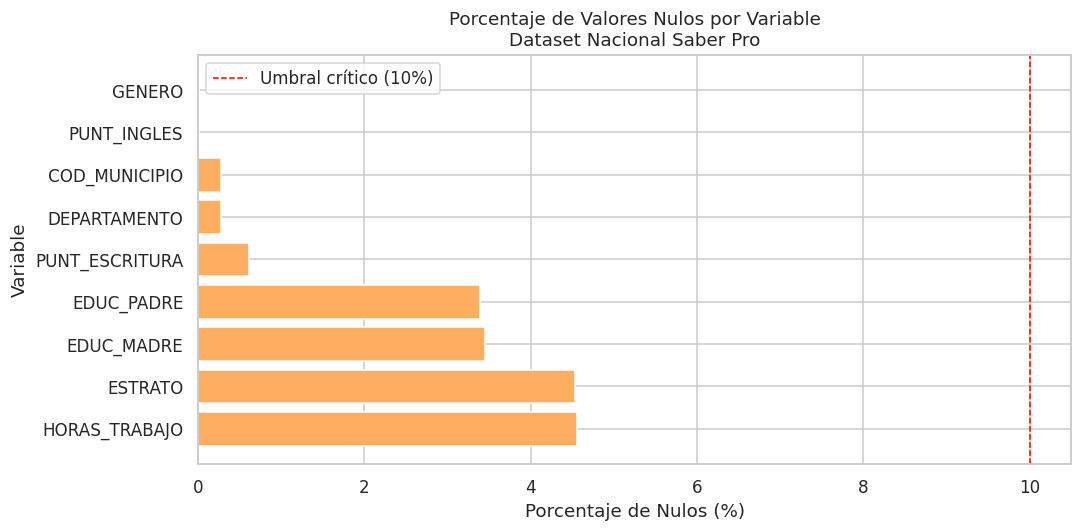

In [21]:
# ─── VISUALIZACIÓN: DISTRIBUCIÓN DE NULOS ────────────────────────────────────
nulos_viz = nulos_pd[nulos_pd['Nulos'] > 0].copy()

if len(nulos_viz) > 0:
    plt.figure(figsize=(10, 5))
    colores = ['#d73027' if p > 10 else '#fdae61' if p > 0 else '#1a9850'
               for p in nulos_viz['Porcentaje (%)']]
    plt.barh(nulos_viz['Variable'], nulos_viz['Porcentaje (%)'], color=colores)
    plt.axvline(x=10, color='red', linestyle='--', linewidth=1,
                label='Umbral crítico (10%)')
    plt.title('Porcentaje de Valores Nulos por Variable\nDataset Nacional Saber Pro')
    plt.xlabel('Porcentaje de Nulos (%)')
    plt.ylabel('Variable')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("✅ No hay variables con valores nulos en el dataset")

---
## 1.10 Filtrar registros del Cauca 2018–2022

Aplicamos dos filtros en cadena:
1. **Departamento:** Solo registros donde `DEPARTAMENTO == 'CAUCA'`
2. **Período:** Solo semestres entre `20181` (primer semestre 2018) y `20222` (segundo semestre 2022)

El método `.cache()` guarda el resultado en memoria RAM para acelerar todas las operaciones del Capítulo 2.

In [22]:
# ─── FILTRAR CAUCA + PERÍODO 2018-2022 ───────────────────────────────────────
df_cauca = df_proyecto.filter(
    (F.col('DEPARTAMENTO') == 'CAUCA') &
    (F.col('PERIODO').between(20181, 20222))
)

# cache() guarda el resultado en memoria para acelerar el análisis
# Sin cache(), PySpark recalcula desde el CSV cada vez
df_cauca.cache()

total_cauca    = df_cauca.count()
total_nacional = df_proyecto.count()

print("=" * 55)
print("  ✅ FILTRO APLICADO CORRECTAMENTE")
print("=" * 55)
print(f"  Registros nacionales:    {total_nacional:,}")
print(f"  Registros Cauca 2018–22: {total_cauca:,}")
print(f"  Representación:          {(total_cauca/total_nacional*100):.2f}% del total")
print("=" * 55)

  ✅ FILTRO APLICADO CORRECTAMENTE
  Registros nacionales:    1,217,482
  Registros Cauca 2018–22: 20,682
  Representación:          1.70% del total


=== REGISTROS DEL CAUCA POR PERÍODO ===
 PERIODO  count
   20183   5013
   20184      1
   20194     13
   20195   5328
   20196      3
   20202      1
   20203   4409
   20212   4279
   20213     10
   20222   1625


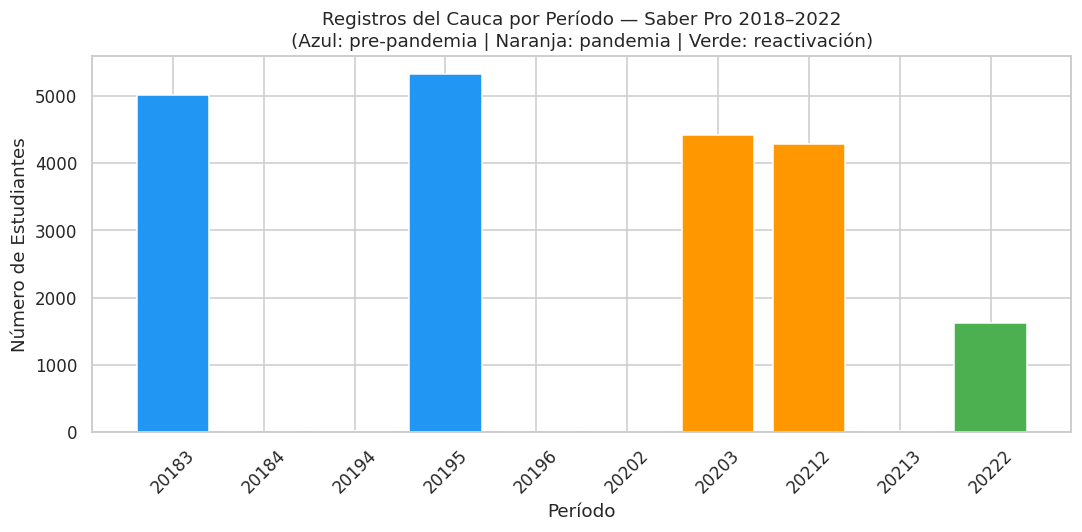

In [23]:
# ─── DISTRIBUCIÓN POR PERÍODO — CAUCA ────────────────────────────────────────
print("=== REGISTROS DEL CAUCA POR PERÍODO ===")
periodos_cauca = df_cauca.groupBy('PERIODO') \
    .count() \
    .orderBy('PERIODO') \
    .toPandas()
print(periodos_cauca.to_string(index=False))

# Gráfico de barras por período
plt.figure(figsize=(10, 5))
colores_p = ['#2196F3' if p < 20200 else '#FF9800' if p < 20220 else '#4CAF50'
             for p in periodos_cauca['PERIODO']]
plt.bar(periodos_cauca['PERIODO'].astype(str),
        periodos_cauca['count'], color=colores_p, edgecolor='white')
plt.title('Registros del Cauca por Período — Saber Pro 2018–2022\n'
          '(Azul: pre-pandemia | Naranja: pandemia | Verde: reactivación)')
plt.xlabel('Período')
plt.ylabel('Número de Estudiantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# ─── DISTRIBUCIÓN POR MUNICIPIO — TOP 10 ─────────────────────────────────────
print("=== TOP 10 MUNICIPIOS DEL CAUCA CON MÁS ESTUDIANTES ===")
df_cauca.groupBy('COD_MUNICIPIO') \
    .count() \
    .orderBy(F.desc('count')) \
    .show(10)

=== TOP 10 MUNICIPIOS DEL CAUCA CON MÁS ESTUDIANTES ===
+-------------+-----+
|COD_MUNICIPIO|count|
+-------------+-----+
|        19001|13135|
|        19698| 1892|
|        19573|  627|
|        19807|  445|
|        19455|  373|
|        19548|  356|
|        19142|  299|
|        19845|  272|
|        19300|  245|
|        19532|  243|
+-------------+-----+
only showing top 10 rows


=== DISTRIBUCIÓN POR ESTRATO — CAUCA ===
    ESTRATO  count
  Estrato 1   7238
  Estrato 2   6457
  Estrato 3   3832
       None   1285
  Estrato 4   1222
  Estrato 5    308
Sin Estrato    258
  Estrato 6     82


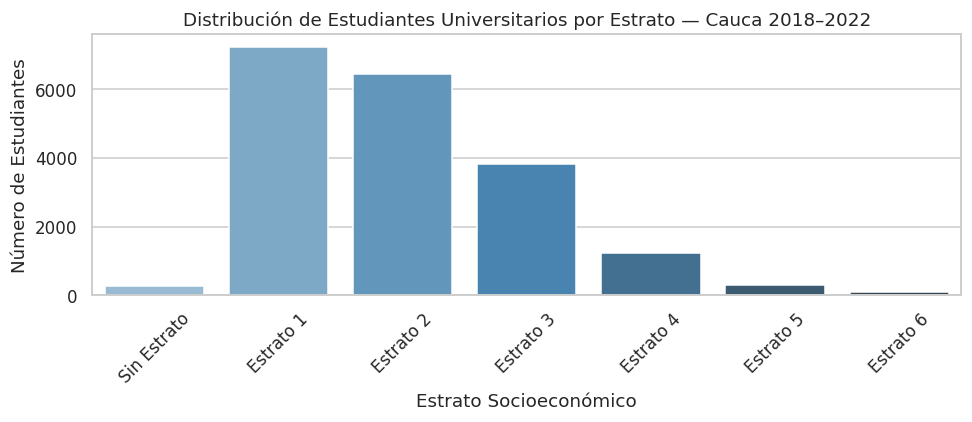

In [25]:
# ─── DISTRIBUCIÓN POR ESTRATO — CAUCA ────────────────────────────────────────
print("=== DISTRIBUCIÓN POR ESTRATO — CAUCA ===")
estrato_dist = df_cauca.groupBy('ESTRATO') \
    .count() \
    .orderBy(F.desc('count')) \
    .toPandas()
print(estrato_dist.to_string(index=False))

plt.figure(figsize=(9, 4))
ORDEN_ESTRATO = ['Sin Estrato','Estrato 1','Estrato 2','Estrato 3',
                 'Estrato 4','Estrato 5','Estrato 6']
estrato_ord = estrato_dist.set_index('ESTRATO').reindex(ORDEN_ESTRATO).dropna()
sns.barplot(x=estrato_ord.index, y=estrato_ord['count'], palette='Blues_d')
plt.title('Distribución de Estudiantes Universitarios por Estrato — Cauca 2018–2022')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Número de Estudiantes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 1.11 Guardar dataset procesado en Google Drive

### ¿Por qué guardar en formato Parquet?
- **Parquet** es un formato columnar optimizado para análisis de datos
- Es **5-10x más rápido** de leer que CSV en PySpark
- Ocupa **menos espacio** que CSV gracias a la compresión automática
- El Capítulo 2 lo leerá directamente desde Drive sin reprocesar el CSV completo

In [26]:
# ─── GUARDAR DATASET DEL CAUCA EN PARQUET ────────────────────────────────────
print("⏳ Guardando dataset del Cauca en Google Drive...")
print(f"   Destino: {RUTA_PARQUET}")

df_cauca.write.mode('overwrite').parquet(RUTA_PARQUET)

# Verificar que se guardó correctamente
if os.path.exists(RUTA_PARQUET):
    print(f"\n✅ Dataset guardado correctamente")
    print(f"   Ruta: {RUTA_PARQUET}")
    print(f"   Registros: {df_cauca.count():,}")
    print("\n📌 En el Capítulo 2 cargue con:")
    print(f'   df_cauca = spark.read.parquet("{RUTA_PARQUET}")')
else:
    print("❌ Error al guardar — verifique el espacio disponible en Drive")

⏳ Guardando dataset del Cauca en Google Drive...
   Destino: /content/drive/MyDrive/SaberPro/cauca_limpio.parquet

✅ Dataset guardado correctamente
   Ruta: /content/drive/MyDrive/SaberPro/cauca_limpio.parquet
   Registros: 20,682

📌 En el Capítulo 2 cargue con:
   df_cauca = spark.read.parquet("/content/drive/MyDrive/SaberPro/cauca_limpio.parquet")


---
## 📋 Resumen del Capítulo 1

Este capítulo completó las dos primeras fases de CRISP-DM para el proyecto Saber Pro Cauca.

In [27]:
# ─── RESUMEN EJECUTIVO DEL CAPÍTULO 1 ────────────────────────────────────────
print("=" * 65)
print("  RESUMEN CAPÍTULO 1 — COMPRENSIÓN DEL CONTEXTO Y LOS DATOS")
print("=" * 65)
print(f"\n  📊 DATASET CARGADO:")
print(f"     Fuente:               ICFES — datos.gov.co")
print(f"     Registros nacionales: {df_proyecto.count():,}")
print(f"     Columnas totales:     57")
print(f"\n  🎯 DATASET PROCESADO:")
print(f"     Registros Cauca:      {df_cauca.count():,}")
print(f"     Variables:            15 (seleccionadas de 57)")
print(f"     Período:              2018–2022 (10 semestres)")
print(f"\n  📚 COMPETENCIAS ANALIZADAS:")
print(f"     1. Razonamiento Cuantitativo")
print(f"     2. Lectura Crítica")
print(f"     3. Comunicación Escrita")
print(f"     4. Inglés")
print(f"     5. Competencias Ciudadanas")
print(f"\n  💾 ARCHIVOS GENERADOS:")
print(f"     cauca_limpio.parquet  → entrada para Capítulo 2")
print(f"\n  ✅ FASES CRISP-DM COMPLETADAS:")
print(f"     Fase 1: Comprensión del negocio  ✅")
print(f"     Fase 2: Comprensión de los datos ✅")
print("=" * 65)
print("  🚀 Siguiente paso: Ejecutar el Capítulo 2 (EDA)")
print("=" * 65)

  RESUMEN CAPÍTULO 1 — COMPRENSIÓN DEL CONTEXTO Y LOS DATOS

  📊 DATASET CARGADO:
     Fuente:               ICFES — datos.gov.co
     Registros nacionales: 1,217,482
     Columnas totales:     57

  🎯 DATASET PROCESADO:
     Registros Cauca:      20,682
     Variables:            15 (seleccionadas de 57)
     Período:              2018–2022 (10 semestres)

  📚 COMPETENCIAS ANALIZADAS:
     1. Razonamiento Cuantitativo
     2. Lectura Crítica
     3. Comunicación Escrita
     4. Inglés
     5. Competencias Ciudadanas

  💾 ARCHIVOS GENERADOS:
     cauca_limpio.parquet  → entrada para Capítulo 2

  ✅ FASES CRISP-DM COMPLETADAS:
     Fase 1: Comprensión del negocio  ✅
     Fase 2: Comprensión de los datos ✅
  🚀 Siguiente paso: Ejecutar el Capítulo 2 (EDA)
